In [ ]:
!pip install ultralytics timm kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00


In [ ]:
import os, cv2, shutil, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch
from torchvision import transforms
import timm
from ultralytics import YOLO
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
FRACATLAS_ROOT = Path("/content/fracatlas_raw/Fracatlas")
os.environ['KAGGLE_USERNAME'] = "evangregor"
os.environ['KAGGLE_KEY'] = "KGAT_ee7af7d4f30a6f968e534c5b38566789"

In [ ]:
!pip install -q kaggle

!kaggle datasets download -d abdohamdg/fracatlas-dataset
!unzip -q fracatlas-dataset.zip -d /content/fracatlas_raw

Dataset URL: https://www.kaggle.com/datasets/abdohamdg/fracatlas-dataset
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 87.6M/87.6M [00:00<00:00, 100MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/mura_dataset.zip"
extract_path = "/content/mura_dataset"

# create folder
os.makedirs(extract_path, exist_ok=True)

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)

✅ Dataset extracted to: /content/mura_dataset


In [ ]:
wrong = Path("/content/fracatlas_raw/Fracatlas/validation/lables")
right = Path("/content/fracatlas_raw/Fracatlas/validation/labels")
if wrong.exists() and not right.exists():
    wrong.rename(right)
    print("✅ Fixed: lables → labels")

✅ Fixed: lables → labels


In [ ]:
FRACATLAS_ROOT = Path("/content/fracatlas_raw/Fracatlas")
MURA_ROOT      = Path("/content/mura_dataset/MURA-v1.1")
MURA_VAL_CSV   = MURA_ROOT / "valid_labeled_studies.csv"

In [ ]:
frac_imgs = []
for split in ["train", "validation", "test"]:
    img_dir = FRACATLAS_ROOT / split / "images"
    if img_dir.exists():
        frac_imgs.extend(list(img_dir.glob("*.jpg")))

print(f"FracAtlas fractured images: {len(frac_imgs)}")

FracAtlas fractured images: 717


In [ ]:
mura_data    = pd.read_csv(MURA_VAL_CSV, header=None)
normal_imgs  = []

for path in mura_data[0]:
    if "negative" not in path:
        continue
    full_path = MURA_ROOT.parent / path
    if not full_path.is_dir():
        continue
    for img_name in sorted(os.listdir(full_path)):
        if img_name.endswith(".png") and not img_name.startswith("._"):
            normal_imgs.append(full_path / img_name)

print(f"MURA normal images        : {len(normal_imgs)}")

MURA normal images        : 1667


In [ ]:
random.seed(42)
random.shuffle(frac_imgs)
random.shuffle(normal_imgs)

N_PER_CLASS = min(150, len(frac_imgs), len(normal_imgs))
test_samples = (
    [(p, 1) for p in frac_imgs[:N_PER_CLASS]] +
    [(p, 0) for p in normal_imgs[:N_PER_CLASS]]
)
random.shuffle(test_samples)
print(f"\nTest set: {len(test_samples)} images | "
      f"Normal: {N_PER_CLASS} | Fractured: {N_PER_CLASS}")


Test set: 300 images | Normal: 150 | Fractured: 150


In [ ]:
EFFNET_CKPT = "/content/drive/MyDrive/models/best_effnet_v4.pth"
YOLO_CKPT   = "/content/drive/MyDrive/models/best.pt"
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt         = torch.load(EFFNET_CKPT, map_location=device, weights_only=False)
cfg          = ckpt["config"]
effnet_model = timm.create_model(
    cfg["model_name"], pretrained=False,
    num_classes=cfg["num_classes"], drop_rate=cfg["drop_rate"]
)
effnet_model.load_state_dict(ckpt["model_state"])
effnet_model = effnet_model.to(device).eval()
print(f"✅ EfficientNet | AUC {ckpt['val_auc']:.4f}")

yolo_model = YOLO(YOLO_CKPT)
print("✅ YOLO loaded")

✅ EfficientNet | AUC 0.9134
✅ YOLO loaded


In [ ]:
def apply_clahe(pil_img, pct=0.04):
    img_np   = np.array(pil_img.convert("L"))
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img_np)
    img      = Image.fromarray(enhanced)
    arr      = np.array(img)
    h, w     = arr.shape[:2]
    mh, mw   = int(h*pct), int(w*pct)
    return Image.fromarray(arr[mh:h-mh, mw:w-mw])

infer_tf = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

In [ ]:
EFFNET_THR = 0.6623
YOLO_CONF  = 0.15
FINAL_THR  = 0.4355
W_E, W_Y   = 0.45, 0.55

results = []
for img_path, true_label in tqdm(test_samples, desc="Evaluating"):
    # EfficientNet
    pil     = apply_clahe(Image.open(img_path).convert("L"))
    tensor  = infer_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        probs   = torch.softmax(effnet_model(tensor), dim=1)[0].cpu().numpy()
    e_score = float(probs[1])

    # YOLO
    yolo_res = yolo_model.predict(
        str(img_path), conf=YOLO_CONF,
        iou=0.45, imgsz=640, verbose=False
    )
    boxes   = yolo_res[0].boxes
    confs   = [float(b.conf[0].cpu()) for b in boxes] \
              if boxes is not None and len(boxes) > 0 else []
    y_score = max(confs, default=0.0)

    # Ensemble
    ens_score  = W_E * e_score + W_Y * y_score
    final_pred = int(ens_score >= FINAL_THR)
    agree      = (e_score >= EFFNET_THR) == (y_score >= YOLO_CONF)
    uncertain  = not agree or 0.40 <= ens_score <= 0.65

    results.append({
        "true"     : true_label,
        "e_score"  : e_score,
        "y_score"  : y_score,
        "ens_score": ens_score,
        "pred"     : final_pred,
        "agree"    : agree,
        "uncertain": uncertain,
    })

Evaluating: 100%|██████████| 300/300 [00:26<00:00, 11.52it/s]


In [ ]:
true    = [r["true"]      for r in results]
e_sc    = [r["e_score"]   for r in results]
y_sc    = [r["y_score"]   for r in results]
ens_sc  = [r["ens_score"] for r in results]
preds   = [r["pred"]      for r in results]
e_preds = [int(s >= EFFNET_THR) for s in e_sc]
y_preds = [int(s >= YOLO_CONF)  for s in y_sc]

def metrics(labels, preds, scores, name):
    auc       = roc_auc_score(labels, scores)
    cm        = confusion_matrix(labels, preds)
    tn,fp,fn,tp = cm.ravel()
    sens      = tp / (tp + fn + 1e-8)
    spec      = tn / (tn + fp + 1e-8)
    print(f"\n── {name} ──")
    print(f"  AUC-ROC     : {auc:.4f}")
    print(f"  Sensitivity : {sens*100:.2f}%")
    print(f"  Specificity : {spec*100:.2f}%")
    print(classification_report(labels, preds,
          target_names=["Normal","Fractured"], zero_division=0))
    return auc, sens, spec

print("\n" + "="*55)
print("SYSTEM-LEVEL EVALUATION")
print("Normal=MURA val | Fractured=FracAtlas")
print("="*55)
auc_e,   sens_e,   spec_e   = metrics(true, e_preds, e_sc,  "EfficientNet Only")
auc_y,   sens_y,   spec_y   = metrics(true, y_preds, y_sc,  "YOLO Only")
auc_ens, sens_ens, spec_ens = metrics(true, preds,   ens_sc,"ENSEMBLE (Combined)")

# Optimal threshold
fpr, tpr, thrs = roc_curve(true, ens_sc)
best_idx        = np.argmax(tpr - fpr)
print(f"\n── Optimal Ensemble Threshold ──")
print(f"  Threshold   : {thrs[best_idx]:.4f}")
print(f"  Sensitivity : {tpr[best_idx]*100:.2f}%")
print(f"  Specificity : {(1-fpr[best_idx])*100:.2f}%")

n_unc = sum(r["uncertain"] for r in results)
print(f"  Uncertain   : {n_unc}/{len(results)} ({n_unc/len(results)*100:.1f}%)")

# Summary table
print("\n" + "="*60)
print(f"{'Metric':<22} {'EfficientNet':>13} {'YOLO':>8} {'Ensemble':>10}")
print("-"*60)
print(f"{'AUC-ROC':<22} {auc_e:>13.4f} {auc_y:>8.4f} {auc_ens:>10.4f}")
print(f"{'Sensitivity':<22} {sens_e*100:>12.1f}% {sens_y*100:>7.1f}% {sens_ens*100:>9.1f}%")
print(f"{'Specificity':<22} {spec_e*100:>12.1f}% {spec_y*100:>7.1f}% {spec_ens*100:>9.1f}%")
print("="*60)



SYSTEM-LEVEL EVALUATION
Normal=MURA val | Fractured=FracAtlas

── EfficientNet Only ──
  AUC-ROC     : 0.9908
  Sensitivity : 99.33%
  Specificity : 88.67%
              precision    recall  f1-score   support

      Normal       0.99      0.89      0.94       150
   Fractured       0.90      0.99      0.94       150

    accuracy                           0.94       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.94      0.94       300


── YOLO Only ──
  AUC-ROC     : 0.8975
  Sensitivity : 88.67%
  Specificity : 75.33%
              precision    recall  f1-score   support

      Normal       0.87      0.75      0.81       150
   Fractured       0.78      0.89      0.83       150

    accuracy                           0.82       300
   macro avg       0.83      0.82      0.82       300
weighted avg       0.83      0.82      0.82       300


── ENSEMBLE (Combined) ──
  AUC-ROC     : 0.9892
  Sensitivity : 96.00%
  Specificity : 94.67%
       

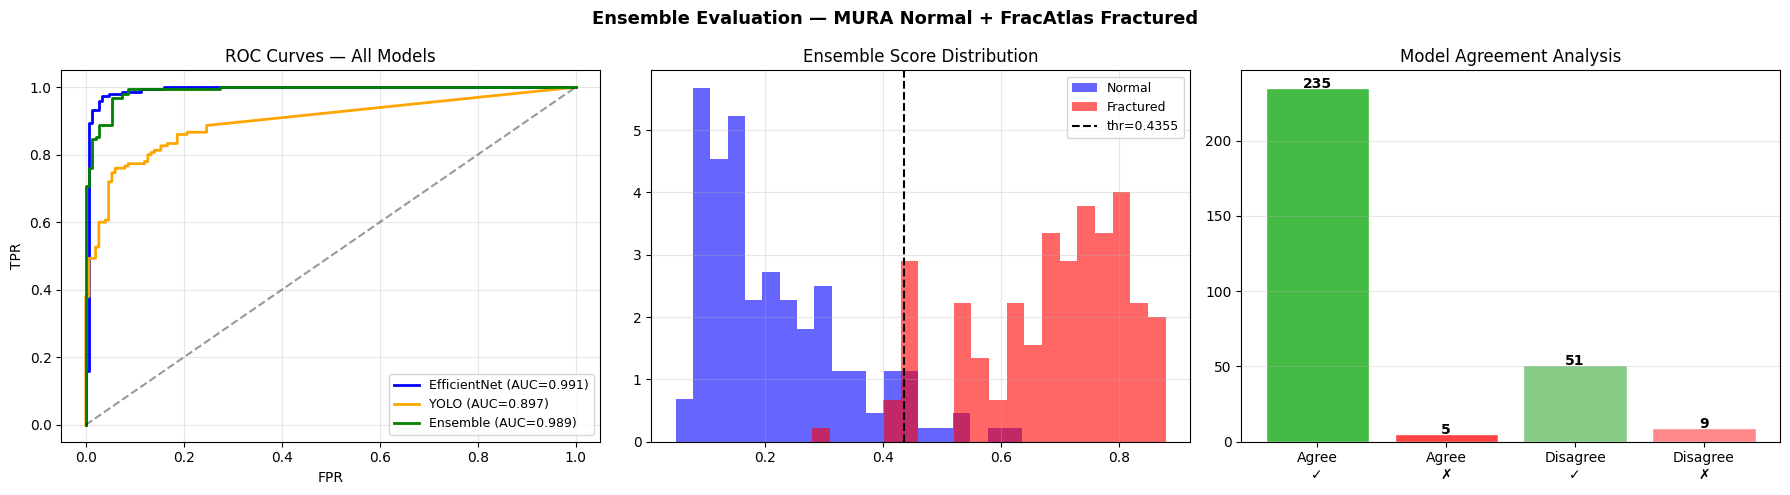


✅ Done — /content/ensemble_eval_final.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for sc, lb, col in [(e_sc,"EfficientNet","blue"),
                     (y_sc,"YOLO","orange"),
                     (ens_sc,"Ensemble","green")]:
    f_, t_, _ = roc_curve(true, sc)
    axes[0].plot(f_, t_, label=f"{lb} (AUC={roc_auc_score(true,sc):.3f})",
                 linewidth=2, color=col)
axes[0].plot([0,1],[0,1],"k--",alpha=0.4)
axes[0].set_title("ROC Curves — All Models")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

n_sc = [r["ens_score"] for r in results if r["true"]==0]
f_sc = [r["ens_score"] for r in results if r["true"]==1]
axes[1].hist(n_sc, bins=20, alpha=0.6, color="blue",
             label="Normal", density=True)
axes[1].hist(f_sc, bins=20, alpha=0.6, color="red",
             label="Fractured", density=True)
axes[1].axvline(FINAL_THR, color="black", linestyle="--",
                label=f"thr={FINAL_THR}")
axes[1].set_title("Ensemble Score Distribution")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

cats = ["Agree\n✓","Agree\n✗","Disagree\n✓","Disagree\n✗"]
vals = [
    sum(1 for r in results if r["agree"]     and r["pred"]==r["true"]),
    sum(1 for r in results if r["agree"]     and r["pred"]!=r["true"]),
    sum(1 for r in results if not r["agree"] and r["pred"]==r["true"]),
    sum(1 for r in results if not r["agree"] and r["pred"]!=r["true"]),
]
cols  = ["#44BB44","#FF4444","#88CC88","#FF8888"]
bars  = axes[2].bar(cats, vals, color=cols, edgecolor="white")
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3, str(v),
                 ha="center", fontweight="bold")
axes[2].set_title("Model Agreement Analysis")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Ensemble Evaluation — MURA Normal + FracAtlas Fractured",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/ensemble_eval_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Done — /content/ensemble_eval_final.png")